# Hands On: K-Means e K-Medoids

## Objetivos
- Preparar e normalizar dados
- Aplicar K-Means e K-Medoids
- Visualizar os clusters encontrados
- Avaliar a qualidade dos agrupamentos com Silhouette Score
- Comparar os resultados dos dois algoritmos

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

## Carregando o Dataset Iris

In [2]:
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## Normalização dos Dados

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## K-Means

In [4]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_scaled)

## K-Medoids

In [5]:
# pip install scikit-learn-extra
from sklearn_extra.cluster import KMedoids
kmedoids = KMedoids(n_clusters=3, random_state=42)
labels_kmedoids = kmedoids.fit_predict(X_scaled)

## PCA para Visualização

In [6]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

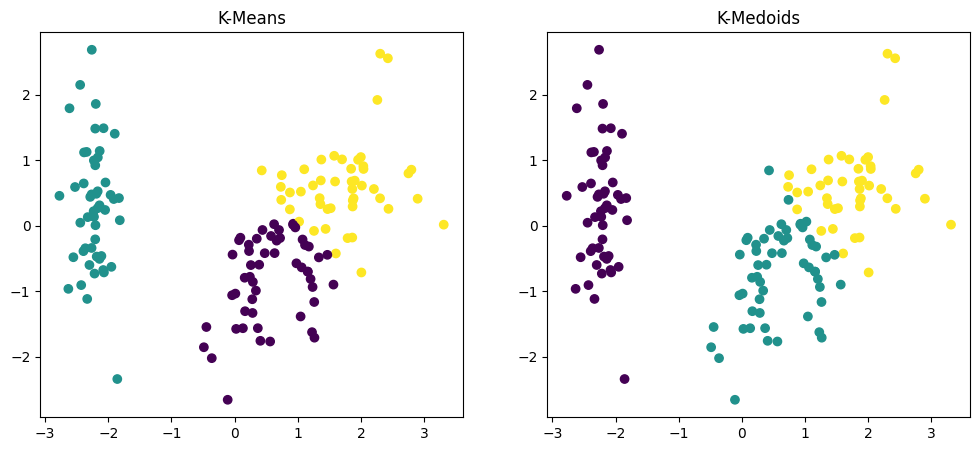

In [7]:
fig, ax = plt.subplots(1,2, figsize=(12,5))
ax[0].scatter(X_pca[:,0], X_pca[:,1], c=labels_kmeans)
ax[0].set_title('K-Means')
ax[1].scatter(X_pca[:,0], X_pca[:,1], c=labels_kmedoids)
ax[1].set_title('K-Medoids')
plt.show()

## Silhouette Score

In [8]:
silhouette_kmeans = silhouette_score(X_scaled, labels_kmeans)
silhouette_kmedoids = silhouette_score(X_scaled, labels_kmedoids)
print(f'K-Means: {silhouette_kmeans:.4f}')
print(f'K-Medoids: {silhouette_kmedoids:.4f}')

K-Means: 0.4599
K-Medoids: 0.4590
